# microsoft/resnet-50
https://arxiv.org/abs/1512.03385

Brain Tumor Probability (Binary Classification)
- Yes: tumor presente
- No: tumor ausente

In [3]:
# pip install scikit-learn
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path

## Hyperparameters (Model Configuration)

| Parameter | Value / Configuration | Rationale / Reference |
| --- | --- | --- |
| **Input Dimensions** | 256 | 256 x 256 pixels square resolution for spatial consistency. |
| **Batch Size** | 8 | Set in accordance with Angelina et al. (2026, p. 9) for memory constraints. |
| **Epochs** | 200 | Incremeneted so it can learn longer. EarlyStopping applied. |
| **Learning Rate** | 0.0001 (Static) | Set in accordance with He et al. (2015, p. 4). |
| **Dropout Rate** | 0.5 | Applied for regularization to mitigate overfitting (Hinton et al., 2012, p. 2). |
| **Activation Function** | Sigmoid | Employed in the final layer for single-class probability mapping. |
| **Loss Function** | Binary Cross-Entropy | Selected to complement the single-neuron sigmoid output. |
| **Optimizer** | Adam | Back propagation optimization. |
| **Data Augmentation** | Rotation, translation, zoom, and contrast | Applied only to training batches to reduce overfitting in the small dataset. |

- He, K., Zhang, X., Ren, S., y Sun, J. (2015). Deep residual learning for image recognition. arXiv. https://doi.org/10.48550/arXiv.1512.03385
- Hinton, G. E., Srivastava, N., Krizhevsky, A., Sutskever, I., y Salakhutdinov, R. R. (2012). Improving neural networks by preventing co-adaptation of feature detectors. arXiv. https://doi.org/10.48550/arXiv.1207.0580
- Angelina, C. L., Xiao, F.-R., Vyas, S., Yang, P.-C., Chang, H.-T., & Luo, Y. (2026). Mod-SE(2): A geometric deep learning framework for brain tumor classification and segmentation in MRI images. Journal of Biomedical Science, 33, Article 11. https://doi.org/10.1186/s12929-025-01213-y

In [9]:
IMG_SIZE = 256
BATCH_SIZE = 8
EPOCHS = 200
LEARNING_RATE = 0.0001
DROPOUT = 0.5
LOSS_METHOD = "binary_crossentropy"
ACTIVATION = "sigmoid"
LABEL_MODE = "binary"
PATIENCE = 10
SEED = 42

THRESHOLD = 0.5

TRAIN_DIR = "data/dataset_ready/train"
VAL_DIR = "data/dataset_ready/val"
TEST_DIR = "data/dataset_ready/test"

MODEL_TAG = "resnet50"

## Dataset Structure
```text
data/dataset_ready/
+-- train/
|   +-- no/
|   +-- yes/
+-- val/
|   +-- no/
|   +-- yes/
+-- test/
    +-- no/
    +-- yes/
```

En TensorFlow/Keras, la asignacion de etiquetas para conjuntos de datos estructurados en carpetas locales no requiere un etiquetado manual en codigo. `image_dataset_from_directory()` infiere las clases por el nombre de las carpetas y las ordena alfabeticamente: `no -> 0`, `yes -> 1`.

El conjunto de **validation** se usa correctamente cuando se pasa como `validation_data=val_ds` en `model.fit()`: sirve para monitorear el entrenamiento, seleccionar el mejor checkpoint y activar early stopping. No debe recibir data augmentation ni debe usarse para reportar el resultado final. El conjunto de **test** se mantiene separado hasta el final para medir el desempeno del modelo ya entrenado.

In [12]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode=LABEL_MODE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode=LABEL_MODE,
    shuffle=False
)

classes = train_ds.class_names # Binary: ['no', 'yes']
num_classes = len(classes)
print(classes)

Found 151 files belonging to 2 classes.
Found 51 files belonging to 2 classes.
['no', 'yes']


## Data Augmentation

Se agrega data augmentation para generar variaciones realistas de las imagenes de entrenamiento sin crear archivos nuevos en disco. En cada epoca, Keras aplica pequenas rotaciones, traslaciones, zoom y cambios de contraste a los batches de `train_ds`.

Esto busca que el modelo no memorice tan facil el dataset pequeno y aprenda patrones mas robustos. La validacion y el test se dejan sin augmentation para medir el desempeno sobre imagenes reales, no transformadas artificialmente.

For the classification head, the two 4096-unit dense layers were removed, as the task involved only two output classes (N=256), making such a high-capacity head unnecessarily complex.
| Block       | Architecture                                |
|-------------|---------------------------------------------|
| **VGG16 Layer 1** | Conv(64) → Conv(64) → MaxPool               |
| **VGG16 Layer 2** | Conv(128) → Conv(128) → MaxPool             |
| **VGG16 Layer 3**| Conv(256) → Conv(256) → Conv(256) → MaxPool |
| **VGG16 Layer 4** | Conv(512) → Conv(512) → Conv(512) → MaxPool |
| **VGG16 Layer 5** | Conv(512) → Conv(512) → Conv(512) → MaxPool |
| **Head (manual)** | Flatten → Dense(1000) → Softmax |
- He, K., Zhang, X., Ren, S., y Sun, J. (2015). Deep residual learning for image recognition. arXiv. https://doi.org/10.48550/arXiv.1512.03385, page 4

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout, GlobalAveragePooling2D
from tensorflow.keras.layers import RandomRotation, RandomTranslation, RandomZoom, RandomContrast

# Data augmentation dentro del modelo: se activa en training y se desactiva en validation/test.
data_augmentation = Sequential(
    [
        RandomRotation(0.05, fill_mode="nearest"),
        RandomTranslation(0.05, 0.05, fill_mode="nearest"),
        RandomZoom(0.10, fill_mode="nearest"),
        RandomContrast(0.10),
    ],
    name="data_augmentation"
)

# Modelo microsoft/resnet-50
base_model = tf.keras.applications.ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False

# Modelo vacio listo para ser añadido con el backbone de renset50
model = Sequential()
model.add(Input(shape=(IMG_SIZE, IMG_SIZE, 3)))
model.add(data_augmentation)
model.add(base_model)

# Head
model.add(GlobalAveragePooling2D())
model.add(Dense(128, activation="relu"))
model.add(Dropout(DROPOUT))

# Output
model.add(Dense(1, activation=ACTIVATION)) # Binary = 1
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 8, 8, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## Compile

In [14]:

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss=LOSS_METHOD,
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.F1Score(name="f1score", threshold=THRESHOLD)
    ]
)

## Train

In [ ]:
# 34 Minutes
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        f"checkpoints/{MODEL_TAG}/{MODEL_TAG}.keras",
        save_best_only=True,
        monitor="val_f1score" # val_ prefijo automático de Keras, f1score de validation no de train
    ),
    tf.keras.callbacks.EarlyStopping(
        patience=PATIENCE,
        restore_best_weights=True
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds, 
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.5099 - auc: 0.5102 - f1score: 0.5843 - loss: 0.8517 - precision: 0.6118 - recall: 0.5591 - val_accuracy: 0.6078 - val_auc: 0.8210 - val_f1score: 0.7500 - val_loss: 0.6290 - val_precision: 0.6122 - val_recall: 0.9677
Epoch 2/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.6424 - auc: 0.6312 - f1score: 0.7453 - loss: 0.7137 - precision: 0.6639 - recall: 0.8495 - val_accuracy: 0.7451 - val_auc: 0.8815 - val_f1score: 0.8116 - val_loss: 0.4998 - val_precision: 0.7368 - val_recall: 0.9032
Epoch 3/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.6623 - auc: 0.6783 - f1score: 0.7302 - loss: 0.6665 - precision: 0.7188 - recall: 0.7419 - val_accuracy: 0.7647 - val_auc: 0.9056 - val_f1score: 0.8286 - val_loss: 0.4613 - val_precision: 0.7436 - val_recall: 0.9355
Epoch 4/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.7152 - auc: 0.8184 - f1score: 0.7725 - loss: 0.4967 - precision: 0.7604 - recall: 0.7849 - v

## Training Curves

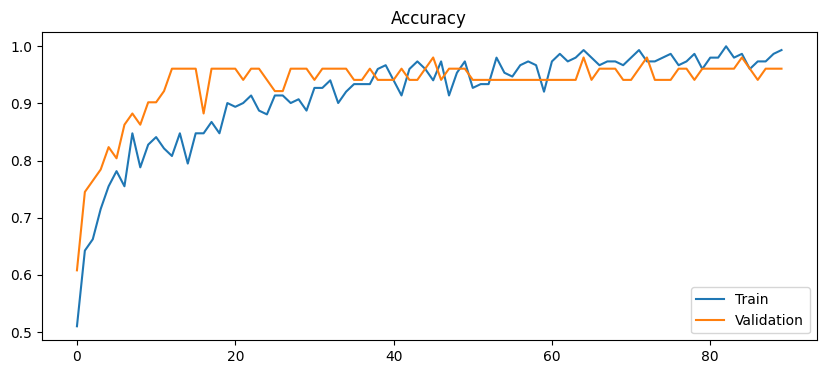

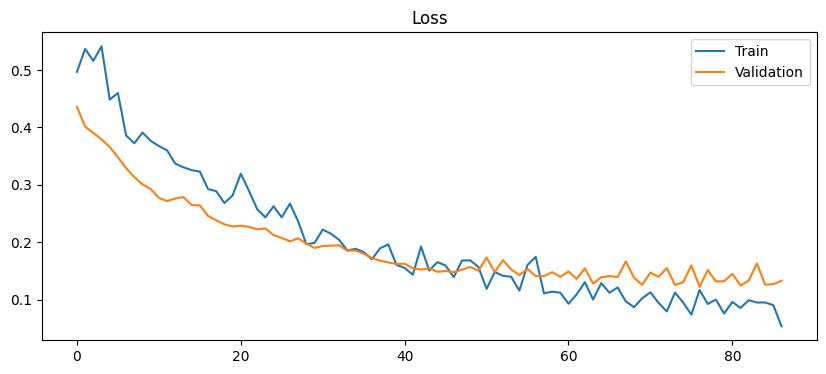

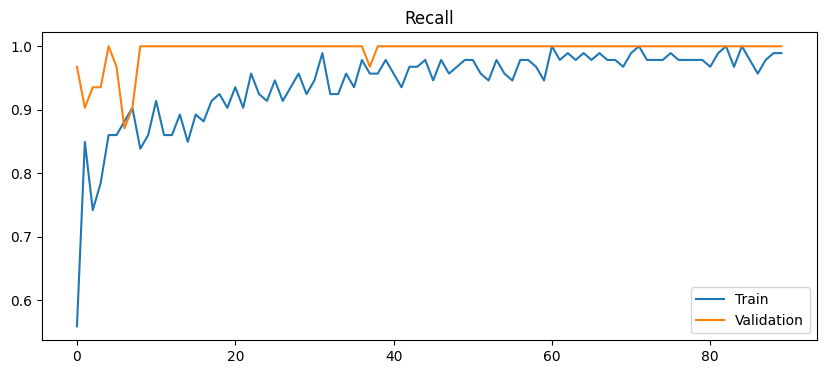

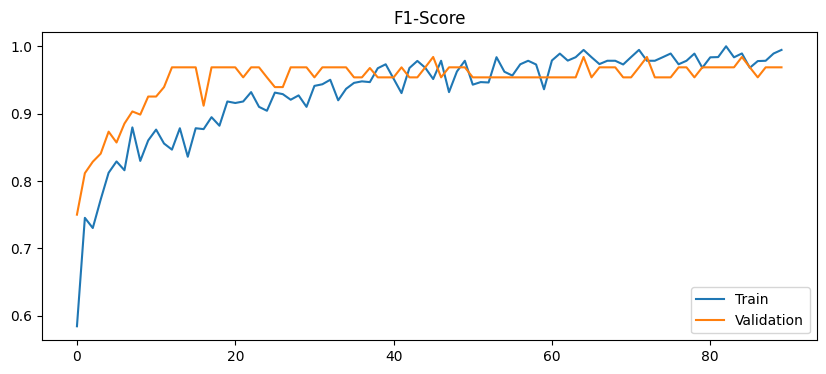

In [16]:
reportPath = os.path.join("reports", MODEL_TAG)
Path(reportPath).mkdir(parents=True, exist_ok=True)

skipEarlyEpochs = 3 # Remueve las primeras 3 epochs (aplastamiento visual de la grafica)

# Accuracy graph
plt.figure(figsize=(10,4))
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.legend(["Train","Validation"])
plt.title("Accuracy")
plt.savefig(os.path.join(reportPath, "accuracy.png"), dpi=300, bbox_inches="tight")
plt.show()

# Loss graph
plt.figure(figsize=(10,4))
plt.plot(history.history["loss"][skipEarlyEpochs:])
plt.plot(history.history["val_loss"][skipEarlyEpochs:]) 
plt.legend(["Train","Validation"])
plt.title("Loss")
plt.savefig(os.path.join(reportPath, "loss.png"), dpi=300, bbox_inches="tight")
plt.show()

# Recall graph
plt.figure(figsize=(10,4))
plt.plot(history.history["recall"])
plt.plot(history.history["val_recall"]) 
plt.legend(["Train","Validation"])
plt.title("Recall")
plt.savefig(os.path.join(reportPath, "recall.png"), dpi=300, bbox_inches="tight")
plt.show()

# F1 score graph
plt.figure(figsize=(10,4))
plt.plot(history.history["f1score"])
plt.plot(history.history["val_f1score"]) 
plt.legend(["Train","Validation"])
plt.title("F1-Score")
plt.savefig(os.path.join(reportPath, "f1score.png"), dpi=300, bbox_inches="tight")
plt.show()

## Save Model is already saved based on f1score performance